In [34]:
# ========================================
# STATIC FUNCTIONAL CONNECTIVITY EXERCISE
# ========================================

# Install needed packages (if not already)
!pip install nilearn

# ===================== LIBRARIES =====================
import os
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
from scipy.stats import zscore

# ============================
# Clone entire Github repository
# ============================

!git clone https://github.com/gpreti/EE-629.git

print("Repository cloned.") #everything exist locally now, path: "EE-629/EX1/"

##### to pull when adding new files into github
#%cd /content/EE-629
#!git pull

Cloning into 'EE-629'...
remote: Enumerating objects: 170, done.
remote: Counting objects: 100% (170/170), done.
remote: Compressing objects: 100% (143/143), done.
remote: Total 170 (delta 51), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (170/170), 69.80 MiB | 18.48 MiB/s, done.
Resolving deltas: 100% (51/51), done.
Repository cloned.


In [35]:
!ls EE-629/EX1/DATA

fMRI_vols  PCCL_ROI.nii  TCS.mat	  yeo_labels.mat
GM.nii	   PCC_ROI.nii	 yeo_labels8.mat


In [ ]:

# ===================== if using google drive =====================
#path_exercise = '/content/drive/MyDrive/ColabNotebooks2026/EE-629/EX_1/'


# Mount Google Drive
#from google.colab import drive
#drive.mount('/content/drive')

path_exercise='EE-629/EX1/'

# ===================== LOAD TIMECOURSES =====================
tcs_file = os.path.join(path_exercise, 'DATA', 'TCS.mat')
tcs = scipy.io.loadmat(tcs_file)
print("Variables in .mat file:", tcs.keys())

# Extract the main timecourse variable
TCSvar = tcs['X1']  # shape: (regions, timepoints, subjects)
print("TCS shape (regions x timepoints x subjects):", TCSvar.shape)

n_regions, n_timepoints, n_subjects = TCSvar.shape


Variables in .mat file: dict_keys(['__header__', '__version__', '__globals__', 'X1'])
TCS shape (regions x timepoints x subjects): (379, 1200, 5)


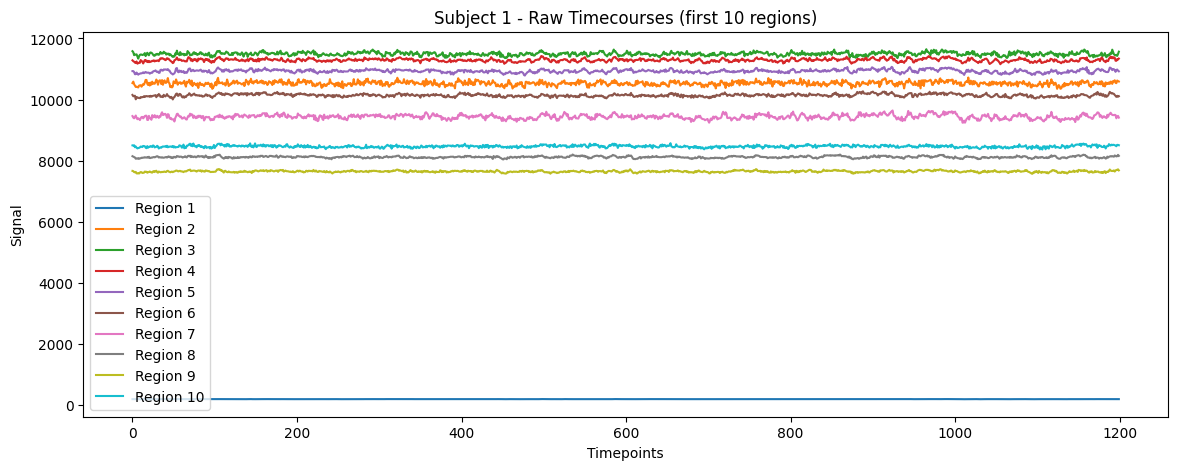

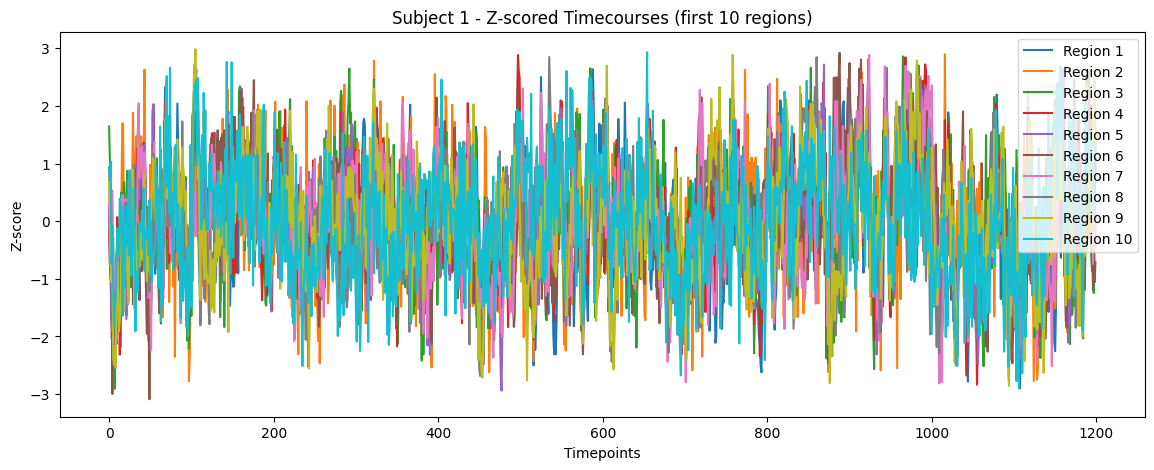

In [ ]:

# ===================== PLOT TIMECOURSES =====================
subject_idx = 0  # first subject
tc_sub = TCSvar[:, :, subject_idx]
tc_sub_z = zscore(tc_sub, axis=1, ddof=1)

# Plot first 10 regions - raw vs z-scored
plt.figure(figsize=(14,5))
for r in range(10):
    plt.plot(tc_sub[r], label=f'Region {r+1}')
plt.title(f"Subject {subject_idx+1} - Raw Timecourses (first 10 regions)")
plt.xlabel("Timepoints")
plt.ylabel("Signal")
plt.legend()
plt.show()

plt.figure(figsize=(14,5))
for r in range(10):
    plt.plot(tc_sub_z[r], label=f'Region {r+1}')
plt.title(f"Subject {subject_idx+1} - Z-scored Timecourses (first 10 regions)")
plt.xlabel("Timepoints")
plt.ylabel("Z-score")
plt.legend()
plt.show()

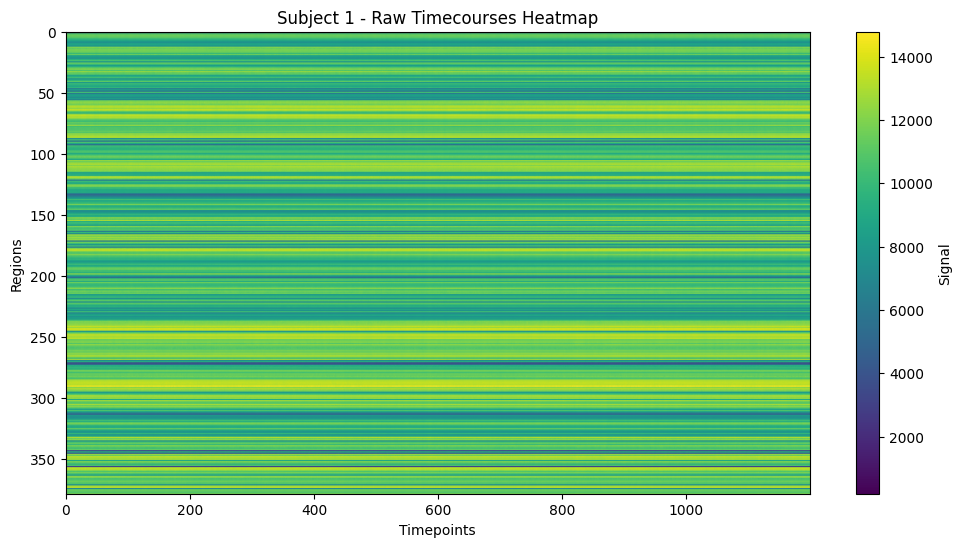

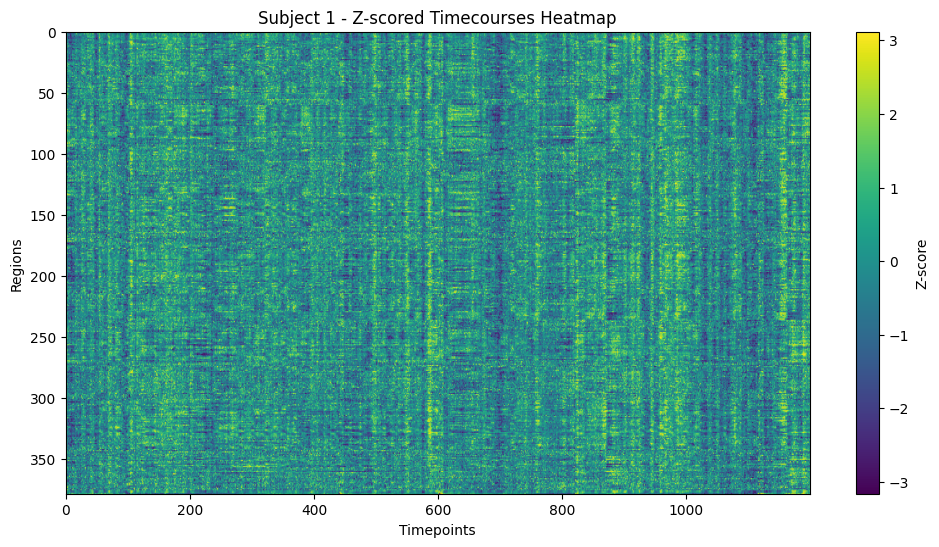

In [ ]:
# ===================== TIMECOURSE HEATMAP =====================
subject_idx = 0  # choose a subject
tc_sub = TCSvar[:, :, subject_idx]
tc_sub_z = zscore(tc_sub, axis=1, ddof=1)

# Raw timecourses heatmap
plt.figure(figsize=(12,6))
plt.imshow(tc_sub, aspect='auto', cmap='viridis')
plt.colorbar(label='Signal')
plt.xlabel('Timepoints')
plt.ylabel('Regions')
plt.title(f'Subject {subject_idx+1} - Raw Timecourses Heatmap')
plt.show()

# Z-scored timecourses heatmap
plt.figure(figsize=(12,6))
plt.imshow(tc_sub_z, aspect='auto', cmap='viridis')
plt.colorbar(label='Z-score')
plt.xlabel('Timepoints')
plt.ylabel('Regions')
plt.title(f'Subject {subject_idx+1} - Z-scored Timecourses Heatmap')
plt.show()

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


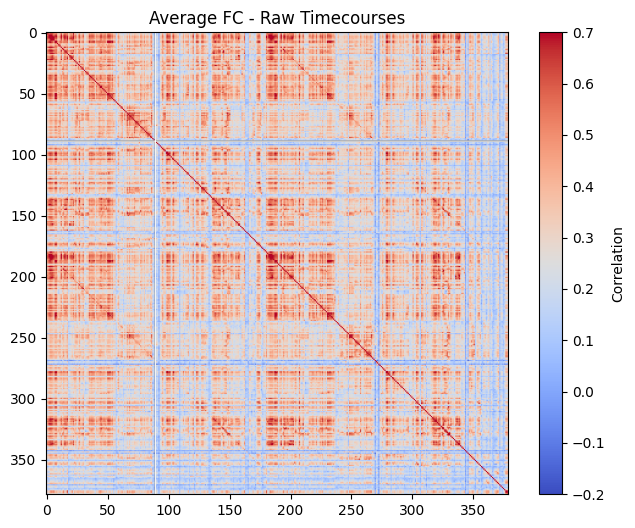

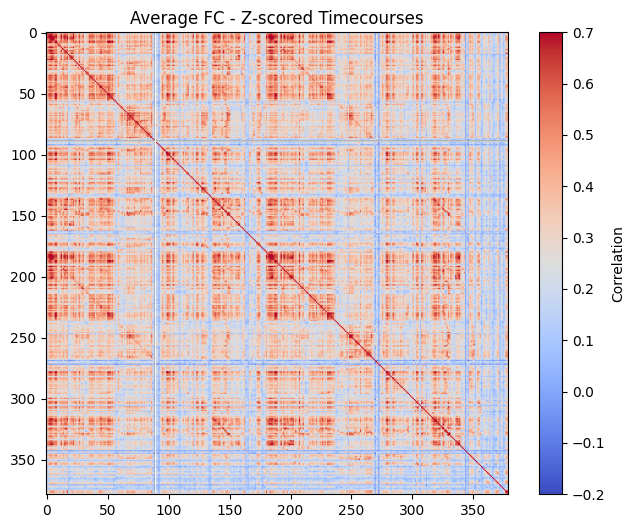

In [ ]:

# ===================== FUNCTIONAL CONNECTIVITY =====================
subject_idx = 0  # example subject
tc_sub = TCSvar[:, :, subject_idx]
tc_sub_z = zscore(tc_sub, axis=1, ddof=1)

# Compute correlation matrices
FC_raw = np.corrcoef(tc_sub)
FC_z = np.corrcoef(tc_sub_z)

# Average across subjects
FC_all = np.zeros((tc_sub.shape[0], tc_sub.shape[0]))
FC_all_z = np.zeros_like(FC_all)
n_subjects = TCSvar.shape[2]
for s in range(n_subjects):
    FC_all += np.corrcoef(TCSvar[:, :, s])
    FC_all_z += np.corrcoef(zscore(TCSvar[:, :, s], axis=1, ddof=1))
FC_all /= n_subjects
FC_all_z /= n_subjects

# ===================== PLOT AVERAGE FC =====================
plt.figure(figsize=(8,6))
plt.imshow(FC_all, cmap='coolwarm', vmin=-0.2, vmax=0.7)
plt.colorbar(label='Correlation')
plt.title('Average FC - Raw Timecourses')
plt.show()

plt.figure(figsize=(8,6))
plt.imshow(FC_all_z, cmap='coolwarm', vmin=-0.2, vmax=0.7)
plt.colorbar(label='Correlation')
plt.title('Average FC - Z-scored Timecourses')
plt.show()



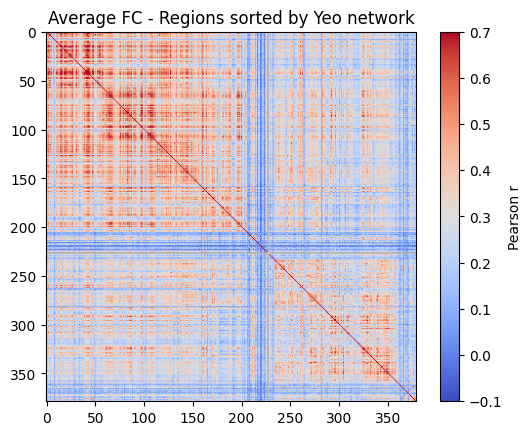

In [43]:
# ===================== REORDER REGIONS BY NETWORK =====================
# Load vector mapping regions to Yeo networks:

yeo_labels_file = os.path.join(path_exercise, 'DATA', 'yeo_labels8.mat')
yeo_dict = scipy.io.loadmat(yeo_labels_file)

yeo_labels_var = yeo_dict['yeo_labels'].squeeze()  # flatten to 1D array


# Then you can reorder:
order = np.argsort(yeo_labels_var)
FC_all_sorted = FC_all[order][:, order]
plt.imshow(FC_all_sorted, cmap='coolwarm', vmin=-0.1, vmax=0.7)
plt.title("Average FC - Regions sorted by Yeo network")
plt.colorbar(label='Pearson r')
plt.show()
